# Image dataset Loading

In [ ]:
import os

file_name = "Task 1 Food Segmentation Dataset.zip"

if os.path.exists(file_name):
  print("File Exists, beginnning unzip")
  !unzip "Task 1 Food Segmentation Dataset"
  print("File unzipped")
else:
  print("File not found, please upload into session")

Streaming output truncated to the last 5000 lines.
  inflating: Task 1 Food Segmentation Dataset/FoodSeg103/Images/img_dir/test/00007107.jpg  
  inflating: Task 1 Food Segmentation Dataset/FoodSeg103/Images/img_dir/test/00007108.jpg  
  inflating: Task 1 Food Segmentation Dataset/FoodSeg103/Images/img_dir/test/00007109.jpg  
  inflating: Task 1 Food Segmentation Dataset/FoodSeg103/Images/img_dir/test/00007110.jpg  
  inflating: Task 1 Food Segmentation Dataset/FoodSeg103/Images/img_dir/test/00007111.jpg  
  inflating: Task 1 Food Segmentation Dataset/FoodSeg103/Images/img_dir/test/00007112.jpg  
  inflating: Task 1 Food Segmentation Dataset/FoodSeg103/Images/img_dir/test/00007113.jpg  
  inflating: Task 1 Food Segmentation Dataset/FoodSeg103/Images/img_dir/test/00007114.jpg  
  inflating: Task 1 Food Segmentation Dataset/FoodSeg103/Images/img_dir/test/00007115.jpg  
  inflating: Task 1 Food Segmentation Dataset/FoodSeg103/Images/img_dir/test/00007116.jpg  
  inflating: Task 1 Food Segm

191.04GB - size of disk after importing zip

In [ ]:
!pip install -q --upgrade keras-hub
!pip install -q --upgrade keras

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "jax"
import keras
from keras import ops
import keras_hub
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
base_path = "Task 1 Food Segmentation Dataset/FoodSeg103/Images/img_dir"
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

# Define basic parameters
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32

# Load training images
train_ds = keras.utils.image_dataset_from_directory(
    train_path,
    label_mode=None,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 4983 files.


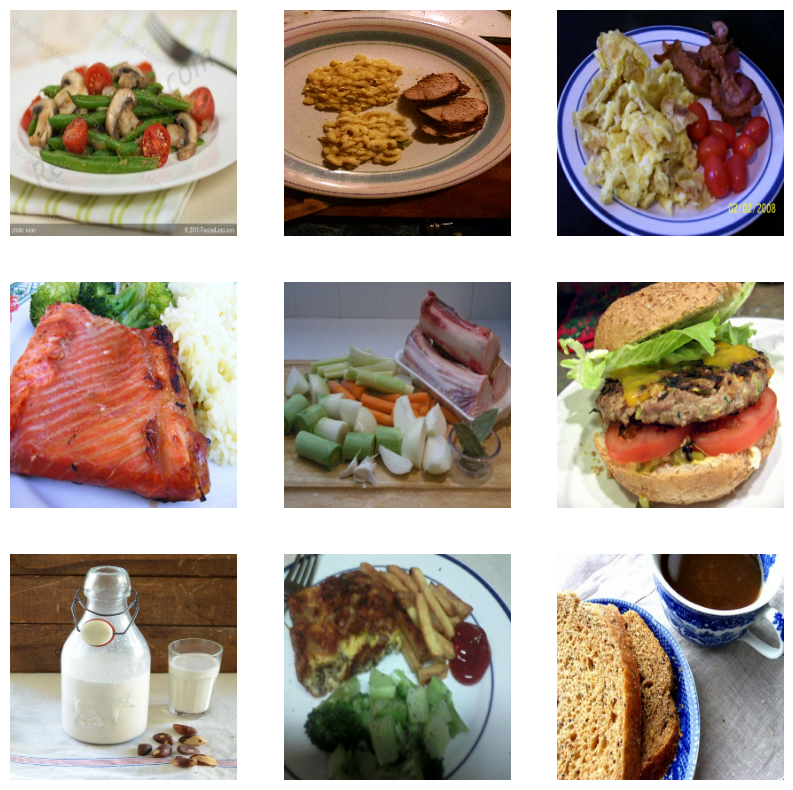

In [ ]:
plt.figure(figsize=(10, 10))
for images in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")
plt.show()

# Load Images and Masks file names

In [ ]:
# Define paths for metadata files
imageset_path = "Task 1 Food Segmentation Dataset/FoodSeg103/ImageSets"
train_txt_path = os.path.join(imageset_path, "train.txt")
test_txt_path = os.path.join(imageset_path, "test.txt")

# Function to read filenames from txt
def read_filenames(file_path):
    with open(file_path, "r") as f:
        # Read lines and strip whitespace/newlines
        filenames = [line.strip() for line in f.readlines() if line.strip()]
    return filenames

# Extract filenames for both splits
train_filenames = read_filenames(train_txt_path)
test_filenames = read_filenames(test_txt_path)

# Print counts to verify against expected sizes (4983 train, 2135 test)
print(f"Number of training filenames: {len(train_filenames)}")
print(f"Number of testing filenames: {len(test_filenames)}")

# Display first 5 filenames for a sanity check
print(f"Sample train filenames: {train_filenames[:5]}")

Number of training filenames: 4983
Number of testing filenames: 2135
Sample train filenames: ['00000000.jpg', '00000001.jpg', '00000002.jpg', '00000003.jpg', '00000004.jpg']


# Load Actual Images and Masks inferred from file names

In [ ]:
# Define the root directories for images and annotations
img_root = "Task 1 Food Segmentation Dataset/FoodSeg103/Images/img_dir"
ann_root = "Task 1 Food Segmentation Dataset/FoodSeg103/Images/ann_dir"

# Helper function to construct paths
def construct_paths(filenames, img_dir, ann_dir):
    img_paths = [os.path.join(img_dir, f) for f in filenames]
    # Masks in FoodSeg103 typically use .png extension
    ann_paths = [os.path.join(ann_dir, f.replace('.jpg', '.png')) for f in filenames]
    return img_paths, ann_paths

# Construct training paths
train_img_paths, train_mask_paths = construct_paths(
    train_filenames,
    os.path.join(img_root, "train"),
    os.path.join(ann_root, "train")
)

# Construct testing paths
test_img_paths, test_mask_paths = construct_paths(
    test_filenames,
    os.path.join(img_root, "test"),
    os.path.join(ann_root, "test")
)

# Verification
print(f"Train: {len(train_img_paths)} images, {len(train_mask_paths)} masks")
print(f"Test:  {len(test_img_paths)} images, {len(test_mask_paths)} masks")

assert len(train_img_paths) == len(train_mask_paths), "Train mismatch!"
assert len(test_img_paths) == len(test_mask_paths), "Test mismatch!"

# Print sample pair
print(f"\nSample Train Image: {train_img_paths[0]}")
print(f"Sample Train Mask:  {train_mask_paths[0]}")
print(f"\nSample Test Image:  {test_img_paths[0]}")
print(f"Sample Test Mask:   {test_mask_paths[0]}")

Train: 4983 images, 4983 masks
Test:  2135 images, 2135 masks

Sample Train Image: Task 1 Food Segmentation Dataset/FoodSeg103/Images/img_dir/train/00000000.jpg
Sample Train Mask:  Task 1 Food Segmentation Dataset/FoodSeg103/Images/ann_dir/train/00000000.png

Sample Test Image:  Task 1 Food Segmentation Dataset/FoodSeg103/Images/img_dir/test/00000048.jpg
Sample Test Mask:   Task 1 Food Segmentation Dataset/FoodSeg103/Images/ann_dir/test/00000048.png


# Preprocess and Augment

In [ ]:
def random_flip(image, mask):
    # Generate a seed for deterministic random operations across image and mask
    seed = tf.random.uniform((2,), minval=0, maxval=10000, dtype=tf.int32)

    # Apply random horizontal flip to image
    image = tf.image.stateless_random_flip_left_right(image, seed=seed)

    # Apply random horizontal flip to mask using the same seed
    mask = tf.image.stateless_random_flip_left_right(mask, seed=seed)

    return image, mask

In [ ]:
def load_and_preprocess(img_path, mask_path):
    # Load and decode image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    # Load and decode mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMAGE_SIZE, method="nearest")
    mask = tf.cast(mask, tf.float32)

    return img, mask

# Create datasets from path lists
train_dataset = tf.data.Dataset.from_tensor_slices((train_img_paths, train_mask_paths))
test_dataset = tf.data.Dataset.from_tensor_slices((test_img_paths, test_mask_paths))

# Map the loading function
train_dataset = train_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# Augment the images
train_dataset = train_dataset.map(random_flip, num_parallel_calls=tf.data.AUTOTUNE)

# Batch and prefetch
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Rebuilt Train Dataset: {len(train_dataset)} batches")
print(f"Rebuilt Test Dataset: {len(test_dataset)} batches")

Rebuilt Train Dataset: 156 batches
Rebuilt Test Dataset: 67 batches


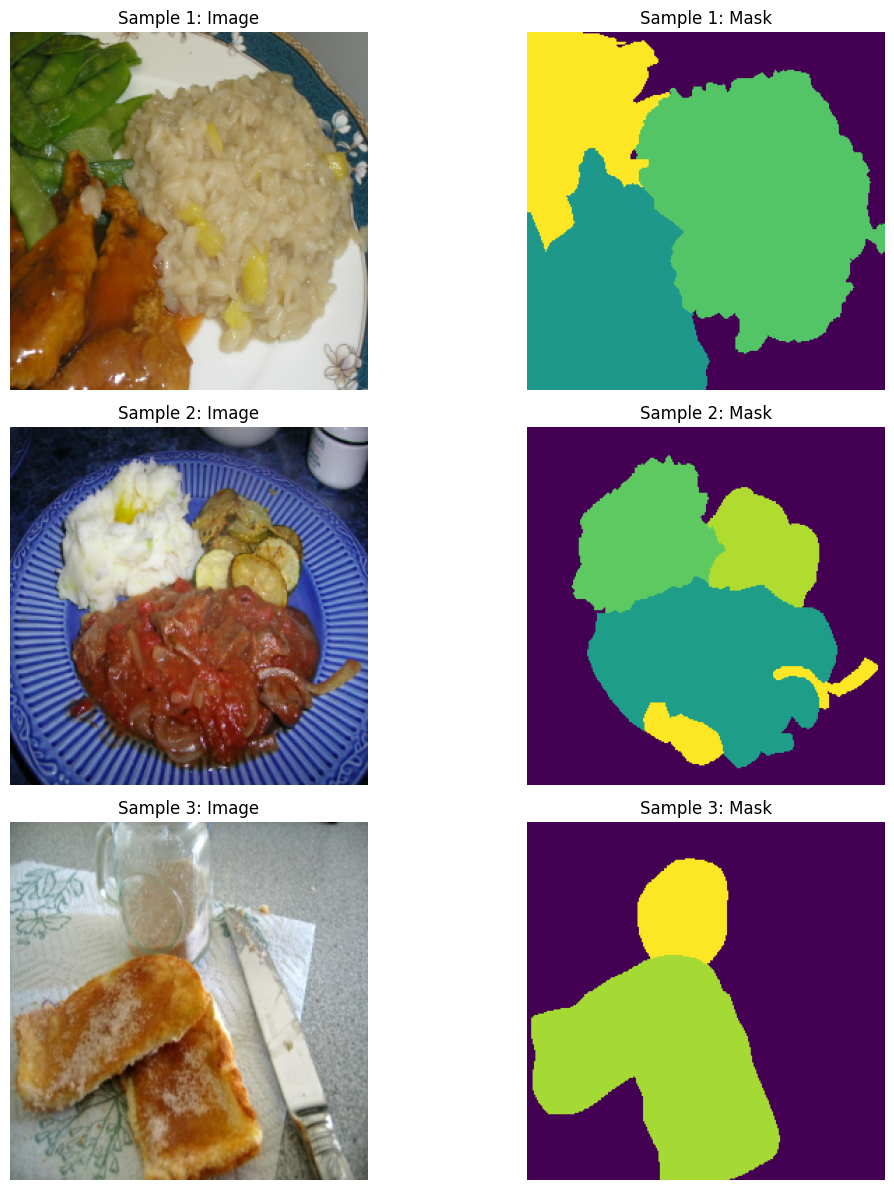

In [ ]:
def visualize_alignment(dataset, num_samples=3):
    plt.figure(figsize=(12, 4 * num_samples))
    for images, masks in dataset.take(1):
        for i in range(num_samples):
            # Display Corrected Image
            ax = plt.subplot(num_samples, 2, 2 * i + 1)
            plt.imshow(images[i].numpy())
            plt.title(f'Sample {i+1}: Image')
            plt.axis('off')

            # Display Corrected Mask
            ax = plt.subplot(num_samples, 2, 2 * i + 2)
            # Squeeze to remove the single channel dimension for visualization
            plt.imshow(ops.squeeze(masks[i]), cmap='viridis')
            plt.title(f'Sample {i+1}: Mask')
            plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize samples from the rebuilt training dataset
visualize_alignment(train_dataset, num_samples=3)

# Model Config Hyperparameters

In [ ]:
INITIAL_LR = 0.007 * BATCH_SIZE / 16
EPOCHS = 50
NUM_CLASSES = 104
learning_rate = keras.optimizers.schedules.CosineDecay(
    INITIAL_LR,
    decay_steps=EPOCHS * 2124,
)

# Model Build

In [ ]:
image_encoder = keras_hub.models.Backbone.from_preset("resnet_50_imagenet")

deeplab_backbone = keras_hub.models.DeepLabV3Backbone(
    image_encoder=image_encoder,
    low_level_feature_key="P2",
    spatial_pyramid_pooling_key="P5",
    dilation_rates=[6, 12, 18],
    upsampling_size=8
)

model = keras_hub.models.DeepLabV3ImageSegmenter(
    backbone=deeplab_backbone,
    num_classes=NUM_CLASSES,
    activation="softmax"
)

100%|██████████| 841/841 [00:00<00:00, 1.55MB/s]


100%|██████████| 90.3M/90.3M [00:00<00:00, 214MB/s]


In [ ]:
model.compile(
    optimizer=keras.optimizers.SGD(
        learning_rate=learning_rate, weight_decay=0.0001, momentum=0.9, clipnorm=10.0
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=[
        keras.metrics.MeanIoU(
            num_classes=NUM_CLASSES, sparse_y_true=False, sparse_y_pred=False
        ),
        keras.metrics.SparseCategoricalAccuracy(),
    ]
)

model.summary()

Model: "deep_lab_v3_image_segmenter"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)                           │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ deep_lab_v3_backbone (DeepLabV3Backbone)      │ (None, None, None, 256)            │          39,190,656 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ segmentation_output (Conv2D)                  │ (None, None, None, 104)            │              26,624 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 39,217,280 (149.60 MB)

 Trainable params: 39,160,480 (149.39 MB)

 Non-trainable params: 56,800 (221.88 KB)

# Model Train

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/backend/jax/core.py:357: UserWarning: Explicitly requested dtype int64 requested in asarray is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.asarray(x, dtype=dtype)


Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - loss: 2.1744 - mean_io_u: 0.0065 - sparse_categorical_accuracy: 0.5363 - val_loss: 2.3666 - val_mean_io_u: 0.0112 - val_sparse_categorical_accuracy: 0.5481
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - loss: 1.5350 - mean_io_u: 0.0089 - sparse_categorical_accuracy: 0.6268 - val_loss: 1.7054 - val_mean_io_u: 0.0086 - val_sparse_categorical_accuracy: 0.6017
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - loss: 1.2966 - mean_io_u: 0.0077 - sparse_categorical_accuracy: 0.6714 - val_loss: 1.5438 - val_mean_io_u: 0.0075 - val_sparse_categorical_accuracy: 0.6145
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - loss: 1.1303 - mean_io_u: 0.0068 - sparse_categorical_accuracy: 0.7060 - val_loss: 1.4506 - val_mean_io_u: 0.0069 - val_sparse_categorical_accuracy: 0.6316
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - loss: 0.9769 - mean_io_u: 0.0065 - sparse_categorical_accuracy: 0.7427 - val_loss: 1.4596 - val_mean_

In [ ]:
model.save("food_segmentation_model.keras")
print("Model saved successfully as food_segmentation_model.keras")

# Evaluate Model

In [ ]:
# Evaluate the model on the test dataset
print("Evaluating model on test set...")
eval_results = model.evaluate(test_dataset)

# Display the results
metrics_names = model.metrics_names
for name, value in zip(metrics_names, eval_results):
    print(f"{name}: {value:.4f}")

Evaluating model on test set...
67/67 ━━━━━━━━━━━━━━━━━━━━ 17s 226ms/step - loss: 1.7975 - mean_io_u: 0.0050 - sparse_categorical_accuracy: 0.6762
loss: 1.7975
compile_metrics: 0.0050


# Test for Demo

/usr/local/lib/python3.12/dist-packages/keras/src/saving/serialization_lib.py:749: UserWarning: `compile()` was not called as part of model loading because the model's `compile()` method is custom. All subclassed Models that have `compile()` overridden should also override `get_compile_config()` and `compile_from_config(config)`. Alternatively, you can call `compile()` manually after loading.
  instance.compile_from_config(compile_config)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 185 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


/usr/local/lib/python3.12/dist-packages/keras/src/backend/jax/core.py:357: UserWarning: Explicitly requested dtype int64 requested in asarray is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.asarray(x, dtype=dtype)


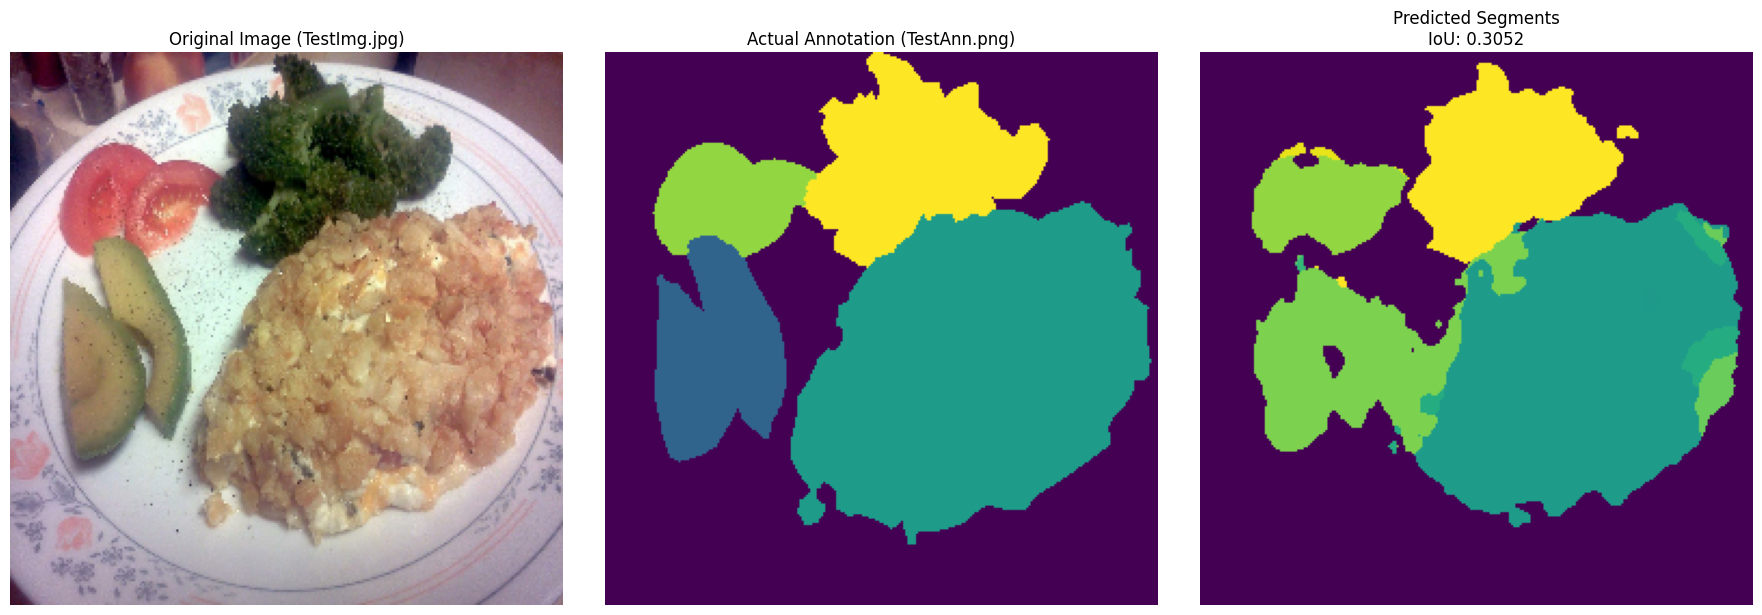

In [ ]:
# 1. Load the model
model_path = 'food_segmentation_model.keras'
loaded_model = keras.models.load_model(model_path)

# 2. Parameters (matching the training config)
IMAGE_SIZE = (256, 256)
NUM_CLASSES = 104

# 3. Preprocess the specific test image and mask
def preprocess_single_pair(img_path, mask_path):
    # Image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    # Mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMAGE_SIZE, method='nearest')
    mask = tf.cast(mask, tf.float32)

    return img, mask

# Load local files
test_img, test_mask = preprocess_single_pair('TestImg.jpg', 'TestAnn.png')

# 4. Inference
# Add batch dimension: (1, 256, 256, 3)
img_batch = tf.expand_dims(test_img, axis=0)
prediction = loaded_model.predict(img_batch)
pred_mask = np.argmax(prediction[0], axis=-1)

# 5. Calculate IoU
iou_metric = keras.metrics.MeanIoU(num_classes=NUM_CLASSES)
iou_metric.update_state(test_mask, pred_mask)
# Fix: Convert JAX array to numpy array explicitly
sample_iou = float(np.array(iou_metric.result()))

# 6. Visualization
plt.figure(figsize=(18, 6))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(test_img.numpy() if hasattr(test_img, 'numpy') else np.array(test_img))
plt.title('Original Image (TestImg.jpg)')
plt.axis('off')

# Ground Truth
plt.subplot(1, 3, 2)
plt.imshow(np.squeeze(np.array(test_mask)), cmap='viridis')
plt.title('Actual Annotation (TestAnn.png)')
plt.axis('off')

# Prediction
plt.subplot(1, 3, 3)
plt.imshow(pred_mask, cmap='viridis')
plt.title(f'Predicted Segments\nIoU: {sample_iou:.4f}')
plt.axis('off')

plt.tight_layout()
plt.show()

# References

1.1    Xiongwei Wu, Xin Fu, Ying Liu, Ee-Peng Lim, Steven C.H. Hoi, Qianru Sun    12 May 2021    A Large-Scale Benchmark for Food Image Segmentation    [Available]: https://arxiv.org/abs/2105.05409    [Accessed on March 20th]

1.2    Sachin Prasad, Divyashree Sreepathihalli, Ian Stenbit    22nd October 2024    Semantic Segmentation with    [Available]: KerasHubhttps://keras.io/keras_hub/guides/semantic_segmentation_deeplab_v3/    [Accessed on March 20th]

1.3    Liang-Chieh Chen, Yukun Zhu, George Papandreou, Florian Schroff, Hartwig Adam    22 Aug 2018    Encoder-Decoder with Atrous Separable Convolution for Semantic Image Segmentation    [Available]: https://arxiv.org/abs/1802.02611 [Accessed on March 20th]
